### 第16章 图像分割与提取
#### 16.1 分水岭算法实现图像分割与提取
- 在用分水岭算法处理图像前，要先使用开运算（先腐蚀，后膨胀）去除图像内的噪声，以避免噪声对图像分割可能造成的干扰
- 通过原始图像和腐蚀图像的减法运算得到图像的边界
- 一般情况下，用”白色“表示前景，用”黑色“表示背景
$$ 未知区域\text{UN} = 图像 - 确定背景 - 确定前景 $$

- 距离变换函数 `dst = cv2. distanceTransform(src, distanceType, maskSize[, dstType])` 计算二值图像内任意点到最近背景点的距离。一般情况下，计算的是图像内非零值像素点到最近的零值像素点的距离
    - `src` 是 8 位单通道的二值图像
    - `distanceType` 为距离类型参数，包括
        - `cv2.DIST_USER`, `cv2.DIST_L1`, `cv2.DIST_L2`, `cv2.DIST_C`, `cv2.DIST_L12`
        - `cv2.DIST_FAIR`, `cv2.DIST_WELSCH`, `cv2.DIST_HUBER`
    - `maskSize` 为掩膜的尺寸，可选`cv2.DIST_MASK_3`, `cv2.DIST_MASK_5`, `cv2.DIST_MASK_PRECISE`
        - 当`distanceType = cv2.DIST_L1 或 cv2.DIST_C` 时，`maskSize` 强制为3
    - `dstType` 为目标图像的类型，默认值为`CV_32F`
    - `dst` 表示计算得到的目标图像，可以是单通道8位或32位浮点数，尺寸和 src 相同

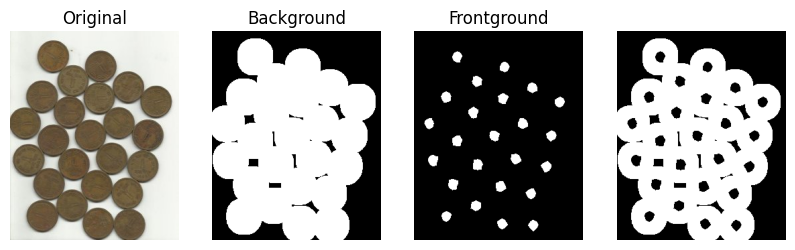

In [5]:
# 标注图像的确定前景、确定背景和未知区域
import numpy as np
import cv2
import matplotlib.pyplot as plt

#  ===========步骤1：图像预处理=================
img = cv2.imread("water_coins.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
#  ==============步骤2：计算确定背景 B==================
kernel = np.ones((3, 3), np.uint8)
Backround = cv2.dilate(opening, kernel, iterations=3)
#  =============步骤3：计算确定前景 F=================
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, fore = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)
Front = np.uint8(fore)
#  ===========步骤4：计算未知区域 Boundry ==================
Unkown = cv2.subtract(Backround, Front)
#  =============步骤5：显示结果======================
ishow = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 色彩空间转换，用于plt显示

plt.figure(figsize=(10, 4))
plt.subplot(141)
plt.imshow(ishow)
plt.title("Original")
plt.axis("off")
plt.subplot(142)
plt.imshow(Backround, cmap="gray")
plt.title("Background")
plt.axis("off")
plt.subplot(143)
plt.imshow(Front, cmap="gray")
plt.title("Frontground")
plt.axis("off")
plt.subplot(144)
plt.imshow(Unkown, cmap="gray")
plt.axis("off")
plt.show()

- 函数 `retval, labels = cv2. connectedComponents(image)` 会将图像背景标注为 0，将其他的对象从 1 开始用正整数标注
    - `image` 是 8 位单通道的待标注图像
    - `retval` 为返回的标注数量
    - `labels` 为标注的结果图像

- 函数 `markers = cv2.watershed(image, markers)` 是实现分水岭算法的函数，其中
    - `image` 是输入图像，必须是 8 位三通道的图像
    - `markers` 是32位单通道的标注，函数会在该参数上进行标注处理，并将对该参数的标注结果作为输出值，作为返回值可省略
    - 对于确定分割的区域被标注位正整数，未确定的区域被标注为0。在对image处理时，会直接修改标注区域markers的值，处理后的markers中，每一个像素要么被设置为初期的”种子值”，要么被视为边界值“-1”

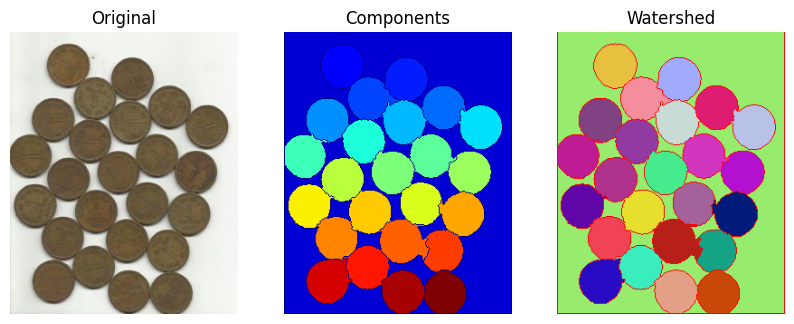

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# ==========步骤1：识别区域（确定前景F、确定背景B、未知区域）============
#  ------------步骤1.1：图像预处理-----------------
img = cv2.imread('water_coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,kernel, iterations=2)
#  ------------步骤1.2：计算确定背景B--------------
kernel = np.ones((3,3),np.uint8)
B = cv2.dilate(opening, kernel, iterations=3)
#  ------------步骤1.3：计算确定前景F--------------
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, fore = cv2.threshold(dist, 0.7*dist.max(), 255,0)
F = np.uint8(fore)
#  -----------步骤1.4：计算未知区域UN--------------
UN = cv2.subtract(B,F)

# =============步骤2：使用函数connectedComponents标注图像 ========
ret, markers = cv2.connectedComponents(F)
# =====步骤3：对函数cv2.connectedComponents()的标注结果进行修订=====
markers = markers + 1  # 数值 1 代表背景区域，从 2 开始代表不同的前景区域
markers[UN==255] = 0   # 将计算出来的未知区域标注为 0，以便将标注结果用于分水岭算法
# print(np.max(markers))   # 25，有24个前景（2-25）

# =============步骤3：使用分水岭函数完成分割 =========
markers = cv2.watershed(img, markers)
# ===============	步骤4：显示处理结果 =============================
#  ------------ 构造分区容器 -----------------
imgWatershed = np.zeros(img.shape, dtype=np.uint8)
#  ------------ 将每一个分区处理为不同颜色 -----------------
for x in range(1, np.max(markers) + 1):
    r = np.random.randint(0, 255)
    g = np.random.randint(0, 255)
    b = np.random.randint(0, 255)
    imgWatershed[markers == x] = [r, g, b]
#  ------------ 将边缘处理为红色 -----------------
imgWatershed[markers == -1] = [0, 0, 255]
#  ------------ 色彩空间转换 -----------------
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgWatershed = cv2.cvtColor(imgWatershed, cv2.COLOR_BGR2RGB)

# =====================步骤5：显示=========================
plt.figure(figsize=(10, 4))
plt.subplot(131)
plt.imshow(ishow)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(markers, cmap="jet")  # "jet" 是一种伪彩色方案，低值显示为蓝色，高值显示为红色
plt.title("Components")
plt.axis('off')

plt.subplot(133)
plt.imshow(imgWatershed, cmap="jet")
plt.title("Watershed")
plt.axis("off")
plt.show()

#### 16.2 交互式前景提取